# Feature Agglomeration and Dendogram

### Imports and Data

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import FeatureAgglomeration
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler

X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')

### First, we'll craft the dendogram to get an idea of some of the trends in the dataset

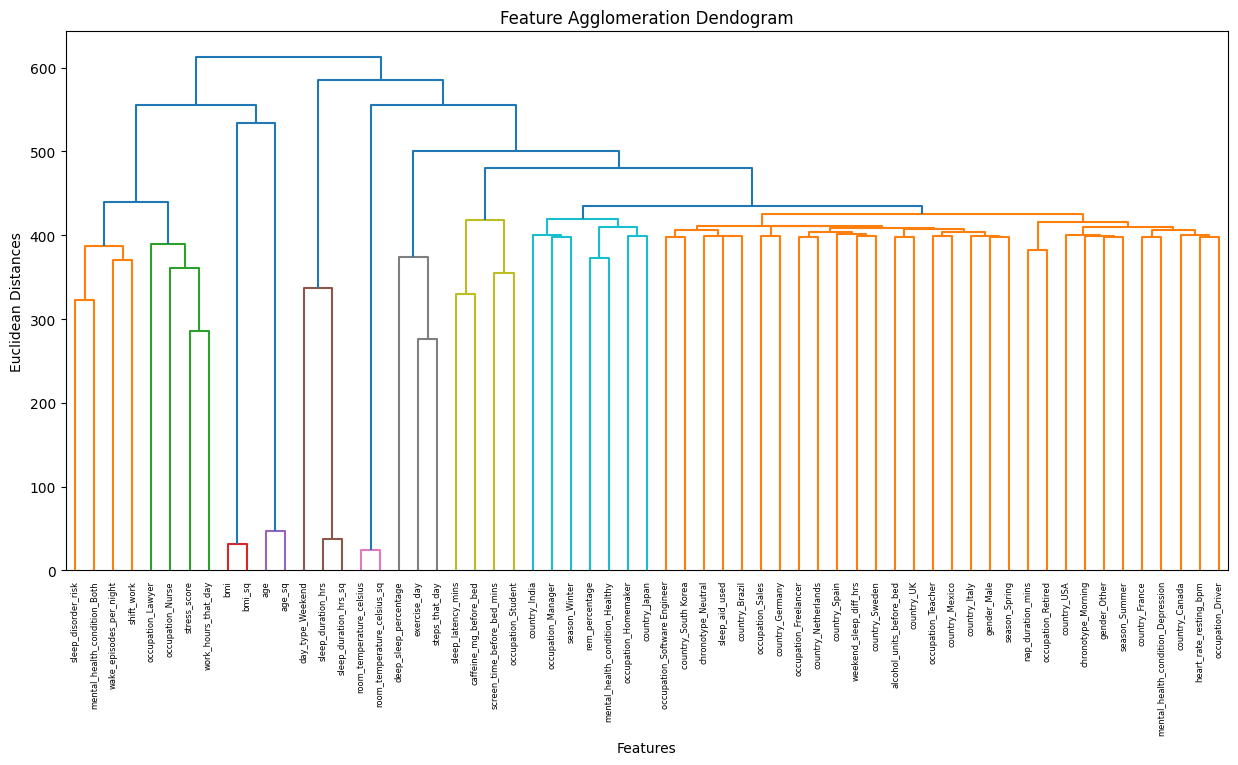

In [39]:
plt.figure(figsize=(15, 7))
linkage_matrix = sch.linkage(X_train.T, method='ward')
dendrogram = sch.dendrogram(linkage_matrix, labels=X_train.columns)

plt.title('Feature Agglomeration Dendogram')
plt.xlabel('Features')
plt.ylabel('Euclidean Distances')
plt.xticks(rotation=90)
plt.show()

### With this, we can implement feature agglomeration

In [40]:
# After some testing, it seems n=15 yields the most interesting groupings
n_clusters = 15

# Perform agglomeration
agglo = FeatureAgglomeration(n_clusters=n_clusters, 
                             linkage='ward')

X_train_reduced = agglo.fit_transform(X_train)
X_test_reduced = agglo.transform(X_test)

# Need to put x_train/x_test back into data frames
column_groups=[f'Feature_Group_{i}' for i in range(n_clusters)]
X_train_cluster = pd.DataFrame(X_train_reduced, 
                               columns=column_groups)

X_test_cluster = pd.DataFrame(X_test_reduced, 
                              columns=column_groups)

print(f"Original shape: {X_train.shape}")
print(f"Reduced shape (train): {X_train_reduced.shape}")
print(f"Reduced shape (test): {X_test_reduced.shape}")

Original shape: (80000, 61)
Reduced shape (train): (80000, 15)
Reduced shape (test): (20000, 15)


### Now we can map those features to clusters

In [41]:
feature_mapping = {}
for i, label in enumerate(agglo.labels_):
    if label not in feature_mapping:
        feature_mapping[label] = []
    feature_mapping[label].append(X_train.columns[i])

for cluster, features in feature_mapping.items():
    print(f"Feature_Group_{cluster}: {features}")

Feature_Group_7: ['age', 'age_sq']
Feature_Group_11: ['bmi', 'bmi_sq']
Feature_Group_13: ['sleep_duration_hrs', 'day_type_Weekend', 'sleep_duration_hrs_sq']
Feature_Group_1: ['rem_percentage', 'occupation_Homemaker', 'country_Japan', 'mental_health_condition_Healthy']
Feature_Group_5: ['deep_sleep_percentage', 'exercise_day', 'steps_that_day']
Feature_Group_12: ['sleep_latency_mins', 'caffeine_mg_before_bed']
Feature_Group_8: ['wake_episodes_per_night', 'shift_work', 'sleep_disorder_risk', 'mental_health_condition_Both']
Feature_Group_0: ['alcohol_units_before_bed', 'weekend_sleep_diff_hrs', 'gender_Male', 'occupation_Freelancer', 'occupation_Sales', 'occupation_Teacher', 'country_Germany', 'country_Italy', 'country_Mexico', 'country_Netherlands', 'country_Spain', 'country_Sweden', 'country_UK', 'season_Spring']
Feature_Group_10: ['screen_time_before_bed_mins', 'occupation_Student']
Feature_Group_14: ['nap_duration_mins', 'occupation_Retired']
Feature_Group_3: ['stress_score', 'work_ho

### We notice that the counries are largely being dumped into residiual bins. Therefore, it is reasonable for us to remove them and see what this does to the groupings

In [42]:
cols_drop_countries = [col for col in X_train.columns if 'country' in col]

X_train_drop_country = X_train.drop(columns=cols_drop_countries)
X_test_drop_country = X_test.drop(columns=cols_drop_countries)

print(f"Dropped the following features: {cols_drop_countries}")

Dropped the following features: ['country_Brazil', 'country_Canada', 'country_France', 'country_Germany', 'country_India', 'country_Italy', 'country_Japan', 'country_Mexico', 'country_Netherlands', 'country_South Korea', 'country_Spain', 'country_Sweden', 'country_UK', 'country_USA']


### Round 2: Feature agglomeration + Mapping - Exclude Countries

In [43]:
# 15 once again appears to be ideal
n_clusters = 15

# Perform agglomeration
agglo = FeatureAgglomeration(n_clusters=n_clusters, 
                             linkage='ward')

X_train_country_reduced = agglo.fit_transform(X_train_drop_country)
X_test_country_reduced = agglo.transform(X_test_drop_country)

# Need to put x_train/x_test back into data frames
column_groups=[f'Feature_Group_{i}' for i in range(n_clusters)]
X_train_occu_cluster = pd.DataFrame(X_train_country_reduced, 
                                    columns=column_groups)

X_test_occu_cluster = pd.DataFrame(X_test_country_reduced, 
                                   columns=column_groups)

print(f"Original shape: {X_train_drop_country.shape}")
print(f"Reduced shape (train): {X_test_drop_country.shape}")
print(f"Reduced shape (test): {X_test_drop_country.shape}")

# Now map
feature_mapping = {}
for i, label in enumerate(agglo.labels_):
    if label not in feature_mapping:
        feature_mapping[label] = []
    feature_mapping[label].append(X_train_drop_country.columns[i])

for cluster, features in feature_mapping.items():
    print(f"Feature_Group_{cluster}: {features}")

Original shape: (80000, 47)
Reduced shape (train): (20000, 47)
Reduced shape (test): (20000, 47)
Feature_Group_7: ['age', 'age_sq']
Feature_Group_11: ['bmi', 'bmi_sq']
Feature_Group_13: ['sleep_duration_hrs', 'day_type_Weekend', 'sleep_duration_hrs_sq']
Feature_Group_1: ['rem_percentage', 'occupation_Homemaker', 'mental_health_condition_Healthy']
Feature_Group_5: ['deep_sleep_percentage', 'exercise_day', 'steps_that_day']
Feature_Group_12: ['sleep_latency_mins', 'caffeine_mg_before_bed']
Feature_Group_10: ['wake_episodes_per_night', 'shift_work', 'sleep_disorder_risk', 'mental_health_condition_Both']
Feature_Group_0: ['alcohol_units_before_bed', 'sleep_aid_used', 'weekend_sleep_diff_hrs', 'gender_Male', 'occupation_Freelancer', 'occupation_Sales', 'occupation_Teacher', 'chronotype_Neutral', 'mental_health_condition_Depression', 'season_Spring']
Feature_Group_8: ['screen_time_before_bed_mins', 'occupation_Student']
Feature_Group_14: ['nap_duration_mins', 'occupation_Retired']
Feature_Gr

### Notice how many of the occupations are being put into junk categories. Lets remove them and undergo another attempt of clustering to see what we find

In [44]:
cols_to_drop = [
    'occupation_Manager',
    'occupation_Software Engineer',
    'occupation_Driver',
    'occupation_Teacher',
    'occupation_Freelancer',
    'occupation_Homemaker',
    'occupation_Sales'
]

X_train_drop_occupation = X_train_drop_country.drop(columns=cols_to_drop)
X_test_drop_occupation = X_test_drop_country.drop(columns=cols_to_drop)

### Round 2: Feature agglomeration + Mapping

In [45]:
# 15 once again appears to be ideal
n_clusters = 15

# Perform agglomeration
agglo = FeatureAgglomeration(n_clusters=n_clusters, 
                             linkage='ward')

X_train_occu_reduced = agglo.fit_transform(X_train_drop_occupation)
X_test_occu_reduced = agglo.transform(X_test_drop_occupation)

# Need to put x_train/x_test back into data frames
column_groups=[f'Feature_Group_{i}' for i in range(n_clusters)]
X_train_occu_cluster = pd.DataFrame(X_train_occu_reduced, 
                                    columns=column_groups)

X_test_occu_cluster = pd.DataFrame(X_test_occu_reduced, 
                                   columns=column_groups)

print(f"Original shape: {X_train_drop_occupation.shape}")
print(f"Reduced shape (train): {X_train_occu_cluster.shape}")
print(f"Reduced shape (test): {X_test_occu_cluster.shape}")

# Now map
feature_mapping = {}
for i, label in enumerate(agglo.labels_):
    if label not in feature_mapping:
        feature_mapping[label] = []
    feature_mapping[label].append(X_train_drop_occupation.columns[i])

for cluster, features in feature_mapping.items():
    print(f"Feature_Group_{cluster}: {features}")

Original shape: (80000, 40)
Reduced shape (train): (80000, 15)
Reduced shape (test): (20000, 15)
Feature_Group_13: ['age', 'age_sq']
Feature_Group_11: ['bmi', 'bmi_sq']
Feature_Group_7: ['sleep_duration_hrs', 'day_type_Weekend', 'sleep_duration_hrs_sq']
Feature_Group_10: ['rem_percentage', 'mental_health_condition_Healthy']
Feature_Group_3: ['deep_sleep_percentage', 'exercise_day', 'steps_that_day']
Feature_Group_12: ['sleep_latency_mins', 'caffeine_mg_before_bed']
Feature_Group_4: ['wake_episodes_per_night', 'shift_work', 'sleep_disorder_risk', 'mental_health_condition_Both']
Feature_Group_6: ['alcohol_units_before_bed', 'gender_Male', 'season_Spring']
Feature_Group_8: ['screen_time_before_bed_mins', 'occupation_Student']
Feature_Group_14: ['nap_duration_mins', 'occupation_Retired']
Feature_Group_5: ['stress_score', 'work_hours_that_day', 'occupation_Lawyer', 'occupation_Nurse']
Feature_Group_0: ['heart_rate_resting_bpm', 'sleep_aid_used', 'chronotype_Neutral', 'mental_health_conditio

### Once again, we see that variables like 'alcohol_units_before_bed' are getting buried with things like gender and season. Lets try removing these to see if the clusters open to some new connections

In [46]:
# while there does seem to be a connection between colder rooms and winter, colder rooms should account for it.
# ill opt to remove winter anyway.
cols_to_drop = [
    'season_Spring',
    'season_Summer',
    'season_Winter',
    'gender_Male',
    'gender_Other'
]
X_train_drop_SG = X_train_drop_occupation.drop(columns=cols_to_drop)
X_test_drop_SG = X_test_drop_occupation.drop(columns=cols_to_drop)

### Round 3: Feature Agglomeration + Mapping

In [47]:
# 15 once again feels good to use; 16 overbins and 14 erases a useful bin distinction between 2 bins
n_clusters = 14

# Perform agglomeration
agglo = FeatureAgglomeration(n_clusters=n_clusters, 
                             linkage='ward')

X_train_SG_reduced = agglo.fit_transform(X_train_drop_SG)
X_test_SG_reduced = agglo.transform(X_test_drop_SG)

# Need to put x_train/x_test back into data frames
column_groups=[f'Feature_Group_{i}' for i in range(n_clusters)]
X_train_SG_cluster = pd.DataFrame(X_train_SG_reduced, 
                                    columns=column_groups)

X_test_SG_cluster = pd.DataFrame(X_test_SG_reduced, 
                                   columns=column_groups)

print(f"Original shape: {X_train_drop_SG.shape}")
print(f"Reduced shape (train): {X_train_SG_cluster.shape}")
print(f"Reduced shape (test): {X_test_SG_cluster.shape}")

# Now map
feature_mapping = {}
for i, label in enumerate(agglo.labels_):
    if label not in feature_mapping:
        feature_mapping[label] = []
    feature_mapping[label].append(X_train_drop_SG.columns[i])

for cluster, features in feature_mapping.items():
    print(f"Feature_Group_{cluster}: {features}")

Original shape: (80000, 35)
Reduced shape (train): (80000, 14)
Reduced shape (test): (20000, 14)
Feature_Group_13: ['age', 'age_sq']
Feature_Group_11: ['bmi', 'bmi_sq']
Feature_Group_7: ['sleep_duration_hrs', 'day_type_Weekend', 'sleep_duration_hrs_sq']
Feature_Group_4: ['rem_percentage', 'mental_health_condition_Healthy']
Feature_Group_8: ['deep_sleep_percentage', 'exercise_day', 'steps_that_day']
Feature_Group_12: ['sleep_latency_mins', 'caffeine_mg_before_bed']
Feature_Group_3: ['wake_episodes_per_night', 'shift_work', 'sleep_disorder_risk', 'mental_health_condition_Both']
Feature_Group_1: ['alcohol_units_before_bed', 'chronotype_Morning']
Feature_Group_10: ['screen_time_before_bed_mins', 'occupation_Student']
Feature_Group_5: ['nap_duration_mins', 'occupation_Retired']
Feature_Group_6: ['stress_score', 'work_hours_that_day', 'occupation_Lawyer', 'occupation_Nurse']
Feature_Group_2: ['heart_rate_resting_bpm', 'mental_health_condition_Depression']
Feature_Group_0: ['sleep_aid_used', 

### This is a good stopping point. We've reached a point in iteration where each grouping can be described in some way. Now, we can go ahead and rename them so when we use them in other models, their groupings have understandable names.

### For clarity, we can name the groups to suit our interpretations of what the model is seeing

In [48]:
group_map = {
    'Feature_Group_0': 'Sleep_Aids_Irregularity',      # Sleep aid used, weekend diff, neutral chronotype
    'Feature_Group_1': 'Alcohol_Morning_Habits',       # Alcohol units, morning chronotype
    'Feature_Group_2': 'Physiological_Mood',           # Heart rate, Depression
    'Feature_Group_3': 'Clinical_Disorder_ShiftWork',  # Wake episodes, shift work, disorder risk, mental health both
    'Feature_Group_4': 'Rem_Healthy_Mental',           # REM %, Healthy mental state
    'Feature_Group_5': 'Retired_Naps',                 # Nap duration, Retired status
    'Feature_Group_6': 'Stress_Corporate',             # Stress score, work hours, Lawyer/Nurse
    'Feature_Group_7': 'Sleep_Amt_Total',              # Duration, Weekend type, Duration squared
    'Feature_Group_8': 'Physical_Activity',            # Deep sleep, exercise, steps
    'Feature_Group_9': 'SleepRoom_Temp',               # Temp and Temp squared
    'Feature_Group_10': 'Screentime_bed_student',      # Screen time, Student status
    'Feature_Group_11': 'bmi_base',                    # BMI and BMI squared
    'Feature_Group_12': 'Evening_Caffeine',            # Sleep latency, Caffeine, Evening chronotype
    'Feature_Group_13': 'age_base'                     # Age and Age squared
}

X_train_SG_cluster.rename(columns=group_map, inplace=True)
X_test_SG_cluster.rename(columns=group_map, inplace=True)

### Now we can export the data for usage

In [49]:
X_train_SG_cluster.to_csv('../data/X_train_cluster_agglom.csv', index=False)
X_test_SG_cluster.to_csv('../data/X_test_cluster_agglom.csv', index=False)
print("Data successfully clustered and exported to 'data/'")

Data successfully clustered and exported to 'data/'
